# Applied Data Science 1 Tutorial 3-1  — Data Preprocessing Tutorial
**Dataset:** Titanic (built into seaborn) ·

You will take a messy Titanic dataset and turn it into model-ready data, then build a leak-free scikit-learn `Pipeline`.

| Task | Topic

| 1 | Data audit
| 2 | Missing values
| 3 | Outliers
| 4 | Encoding & scaling
| 5 | Pipeline & leakage

After every task there is a **justification cell**. Code without reasoning earns partial credit at most.

## Setup

In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", 50)
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Task 1 — Data audit (10 min)
Build a **data quality table** with one row per column showing: dtype, number missing, % missing, and number of unique values.
Then check for duplicate rows and look for columns that repeat the same information.

In [62]:
# TODO: build a DataFrame called `audit` with columns dtype, n_missing, pct_missing, n_unique
def create_audit(df):
  audit = pd.DataFrame({
      "dtype": df.dtypes,
      "n_missing": df.isnull().sum(),
      "pct_missing": round(df.isnull().mean() * 100, 2),
      "n_unique": df.nunique()
  })
  return audit

create_audit(df)

,dtype,n_missing,pct_missing,n_unique
survived,int64,0,0.00,2
pclass,int64,0,0.00,3
sex,object,0,0.00,2
age,float64,177,19.87,88
sibsp,int64,0,0.00,7
parch,int64,0,0.00,7
fare,float64,0,0.00,248
embarked,object,2,0.22,3
class,category,0,0.00,3
who,object,0,0.00,3


In [63]:
# TODO: print the shape, the number of duplicate rows, and the numeric summary

def display_audit(df):
  print("Shape of dataset:", df.shape)
  print("Number of duplicate rows:", df.duplicated().sum())
  print("\nNumeric summary:")
  display(df.describe())

display_audit(df)

Shape of dataset: (891, 15)
Number of duplicate rows: 107

Numeric summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [64]:
# TODO: use pd.crosstab to compare pclass vs class, embarked vs embark_town, and survived vs alive.
# Which columns are redundant? Which one would leak the target?

def crosstab_comparison(df, col1, col2):
  print(f"{col1} vs {col2}")
  display(pd.crosstab(df[col1], df[col2]))
  print("\n")

crosstab_comparison(df, "pclass", "class")
crosstab_comparison(df, "embarked", "embark_town")
crosstab_comparison(df, "survived", "alive")

print("class is redundant")
print("embark_town is redundant")
print("alive would leak the target")

pclass vs class


class,First,Second,Third
pclass,,,
1,216,0,0
2,0,184,0
3,0,0,491




embarked vs embark_town


embark_town,Cherbourg,Queenstown,Southampton
embarked,,,
C,168,0,0
Q,0,77,0
S,0,0,644




survived vs alive


alive,no,yes
survived,,
0,549,0
1,0,342




class is redundant
embark_town is redundant
alive would leak the target


**Justify your choices (2–3 sentences).** What did you choose, what evidence from *your* output supports it, and what is the trade-off or risk?

*Your answer:*
- class is redundant because it's a text and pclass is numeric (First = 1, Second = 2, Third = 3)
- embark_town is redundant because it's a spelled-out text of town rather than single-character column which is embarked (Cherbourg = C, Queenstown = Q, Southampton = S)
- alive is leaky because it's a text and the same as survived which is the target of the model (yes = 1, no = 0)

**Trade-off or risk:** Keeping the redundant ones can be considered as duplicated column which is unnecessary and can affect the training speed of the model. Keeping the leaky one will have a huge risk of target leakage.

## Task 2 — Missing values (10 min)
1. Drop the columns you decided are redundant or leaky, and decide what to do with `deck`.
2. Fill `embark_town` (only 2 missing).
3. Compare **three** ways of imputing `age`: overall mean, median by `pclass` × `sex`, and KNN. Plot the distributions against the original.

In [65]:
# TODO: drop redundant / leaky columns (and deck?), fill embark_town with the mode,
# then check the missing rate of age by pclass

def fill_missing_values(df):
  data = df.drop(columns=["class", "embark_town", "alive", "deck", "who", "adult_male"])
  data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])

  age_missing_by_pclass = data.groupby("pclass")["age"].apply(lambda s: s.isnull().mean() * 100)

  print("Missing rate of age by pclass (%):")
  print(age_missing_by_pclass)
  return data

data = fill_missing_values(df)

Missing rate of age by pclass (%):
pclass
1    13.888889
2     5.978261
3    27.698574
Name: age, dtype: float64


In [66]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


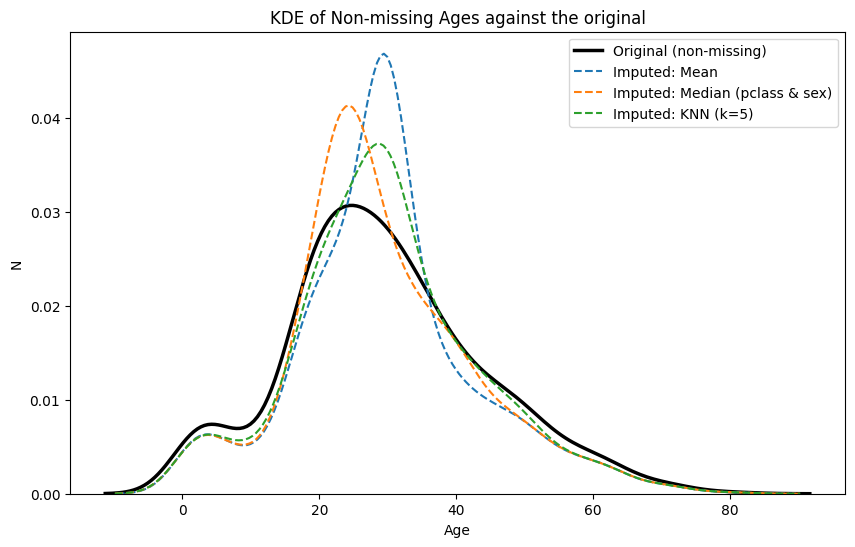

,Original,Overall Mean,Group Median,KNN (k=5)
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,29.699118,29.112424,29.863791
std,14.526497,13.002015,13.304424,13.389283
min,0.420000,0.420000,0.420000,0.420000
25%,20.125000,22.000000,21.500000,22.000000
50%,28.000000,29.699118,26.000000,29.000000
75%,38.000000,35.000000,36.000000,37.000000
max,80.000000,80.000000,80.000000,80.000000


In [67]:
# TODO: create age_mean, age_group (median by pclass and sex) and age_knn (KNNImputer, k=5)
# then plot all three KDEs against the original, non-missing ages, and compare describe() outputs

def impute_age(data):
  age_mean = data["age"].fillna(data["age"].mean())
  age_group = data["age"].fillna(data.groupby(["pclass", "sex"])["age"].transform("median"))
  knn_imputer = KNNImputer(n_neighbors=5)
  # fit KNNImputer on numeric columns: pclass, age, sibsp, parch, fare
  numeric_cols = ["pclass", "age", "sibsp", "parch", "fare"]
  knn_imputed_array = knn_imputer.fit_transform(data[numeric_cols])
  age_knn = pd.Series(knn_imputed_array[:, 1], index=data.index)

  plt.figure(figsize=(10, 6))
  sns.kdeplot(data["age"].dropna(), label="Original (non-missing)", color="black", linewidth=2.5)
  sns.kdeplot(age_mean, label="Imputed: Mean", linestyle="--")
  sns.kdeplot(age_group, label="Imputed: Median (pclass & sex)", linestyle="--")
  sns.kdeplot(age_knn, label="Imputed: KNN (k=5)", linestyle="--")

  plt.title("KDE of Non-missing Ages against the original")
  plt.xlabel("Age")
  plt.ylabel("N")
  plt.legend()
  plt.show()

  # Compare descriptive statistics
  comparison_df = pd.DataFrame({
      "Original": data["age"].describe(),
      "Overall Mean": age_mean.describe(),
      "Group Median": age_group.describe(),
      "KNN (k=5)": age_knn.describe()
  })
  display(comparison_df)

impute_age(data)

**Justify your choices (2–3 sentences).** What did you choose, what evidence from *your* output supports it, and what is the trade-off or risk?

*Your answer:*
- **Choice:** I choose the Median (by pclass and sex) because looking at the plot, it's the most similar looking to the normal line.
- **Evidence:** The overall mean and KNN create a spike at around 30 in the plot, meanwhile Median creates a spike at around 25, the same as the normal line.
- **Trade-off/Risk:** Median is fast and interpretable, but it fills every single missing age with the exact same median value which can underestimate the true variation and lead to biased or overconfident predictions. KNN shows realistic std or variance better but increases complexity and introduces risk of leakage if not carefully pipelined.

## Task 3 — Outliers in `fare` (8 min)
1. Use the **IQR rule** to count fare outliers.
2. Look at the most expensive tickets: errors or genuine?
3. Try **capping** at the upper bound and a **log1p** transform. Compare skewness and plot before/after.

In [68]:
# TODO: compute Q1, Q3, IQR and the bounds; count outliers; inspect their pclass and the top 5 fares

def count_outliers(data):
  Q1 = data["fare"].quantile(0.25)
  Q3 = data["fare"].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = data[data['fare'] > upper_bound]

  print(f"Q1 (25th percentile): {Q1:.2f}")
  print(f"Q3 (75th percentile): {Q3:.2f}")
  print(f"IQR: {IQR:.2f}")
  print(f"Upper Bound (for outliers): {upper_bound:.2f}\n")

  print(f"Number of outliers: {len(outliers)}")
  print("\nOutlier count by Passenger Class:")
  print(outliers["pclass"].value_counts())

  print("\nTop 5 most expensive fares:")
  display(data["fare"].nlargest(5))
  return upper_bound

upper_bound = count_outliers(data)

Q1 (25th percentile): 7.91
Q3 (75th percentile): 31.00
IQR: 23.09
Upper Bound (for outliers): 65.63

Number of outliers: 116

Outlier count by Passenger Class:
pclass
1    104
3      7
2      5
Name: count, dtype: int64

Top 5 most expensive fares:


,fare
258,512.3292
679,512.3292
737,512.3292
27,263.0000
88,263.0000


Original Fare: 4.79
Capped Fare: 1.08
Log-Transformed Fare: 0.39



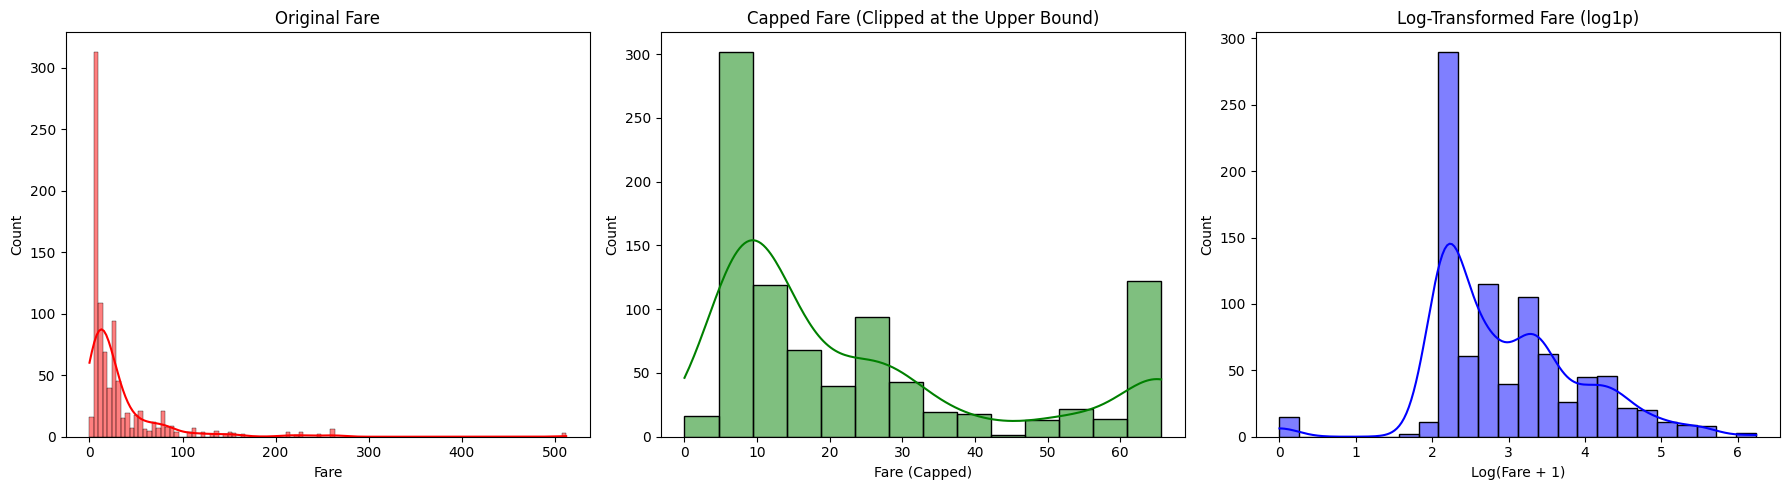

In [69]:
# TODO: create fare_cap (clip at the upper bound) and fare_log (np.log1p);
# print the skewness of all three and plot three histograms side by side

def compare_skewness(data):
  data["fare_cap"] = data["fare"].clip(upper=upper_bound)
  data["fare_log"] = np.log1p(data["fare"])

  print(f"Original Fare: {data["fare"].skew():.2f}")
  print(f"Capped Fare: {data["fare_cap"].skew():.2f}")
  print(f"Log-Transformed Fare: {data["fare_log"].skew():.2f}\n")

  fig, axes = plt.subplots(1, 3, figsize=(18, 5))

  sns.histplot(data["fare"], kde=True, ax=axes[0], color="red")
  axes[0].set_title("Original Fare")
  axes[0].set_xlabel("Fare")

  sns.histplot(data["fare_cap"], kde=True, ax=axes[1], color="green")
  axes[1].set_title("Capped Fare (Clipped at the Upper Bound)")
  axes[1].set_xlabel("Fare (Capped)")

  sns.histplot(data["fare_log"], kde=True, ax=axes[2], color="blue")
  axes[2].set_title("Log-Transformed Fare (log1p)")
  axes[2].set_xlabel("Log(Fare + 1)")

  plt.tight_layout()
  plt.show()

compare_skewness(data)

**Justify your choices (2–3 sentences).** What did you choose, what evidence from *your* output supports it, and what is the trade-off or risk?

*Your answer:*
- **Choice:** I choose the **Log-Transformed Fare (log1p)** over capping for model training because of the lower skewness.
- **Evidence:** The original fare distribution is highly right-skewed with a skewness of 4.79. Capping at the upper IQR bound reduces skewness to 1.08 but creates a large stack of clipped values at the right tail (end). The log-transformation (log1p) handles skewness most effectively 0.39, which creates a normal-like bell curve and is better for most machine learning algorithms.
- **Trade-off/Risk:** Capping risks discarding the actual variations in high-end ticket values by grouping them all at the same value (if someone pays for a very expensive ticket, it's capped by the upper bound). Log-transformation creates the original ordering and relative differences of all values but makes the feature coefficients less directly interpretable in linear models without exponentiating them back.

## Task 4 — Encoding and scaling (7 min)
Split first (stratified, `random_state=42`), then on the **training set only**:
- one-hot encode `sex`, `embark_town`, `alone`
- keep `pclass` as an ordinal number
- standardise `age`, `fare` (log1p), `sibsp`, `parch`

Then apply the fitted transformers to the test set.

In [70]:
# TODO: split (stratify=y, test_size=0.2, random_state=42), log1p the fare,
# fit an imputer, scaler and one-hot encoder on X_train ONLY, and transform both sets

def encode_and_scale(data):
  y = data["survived"]
  X = data.drop(columns=["survived"])

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, stratify=y, test_size=0.2, random_state=42
  )

  X_train["fare"] = np.log1p(X_train["fare"])
  X_test["fare"] = np.log1p(X_test["fare"])

  num_cols = ["age", "fare", "sibsp", "parch"]
  cat_cols = ["sex", "embarked", "alone"]

  imputer = SimpleImputer(strategy="median")
  X_train["age"] = imputer.fit_transform(X_train[["age"]])
  X_test["age"] = imputer.transform(X_test[["age"]])

  scaler = StandardScaler()
  X_train_num = scaler.fit_transform(X_train[num_cols])
  X_test_num = scaler.transform(X_test[num_cols])

  encoder = OneHotEncoder(sparse_output=False, drop="first")
  X_train_cat = encoder.fit_transform(X_train[cat_cols])
  X_test_cat = encoder.transform(X_test[cat_cols])

  X_train_pclass = X_train[["pclass"]].values
  X_test_pclass = X_test[["pclass"]].values

  X_train_trans = np.hstack([X_train_pclass, X_train_num, X_train_cat])
  X_test_trans = np.hstack([X_test_pclass, X_test_num, X_test_cat])

  print("Transformed X_train shape:", X_train_trans.shape)
  print("Transformed X_test shape:", X_test_trans.shape)

encode_and_scale(data)

Transformed X_train shape: (712, 9)
Transformed X_test shape: (179, 9)


**Justify your choices (2–3 sentences).** What did you choose, what evidence from *your* output supports it, and what is the trade-off or risk?

*Your answer:*

- **Choice & Evidence:**
  - **SimpleImputer(strategy='median'):** because median shows a better output plot in Task 2
  - **StandardScaler():** because distance-based and gradient-descent algorithms (such as Logistic Regression) perform optimally when numerical features are on a comparable scale (mean=0, variance=1). This is supported by the final processed dataset containing mixed feature distributions.

- **Trade-off & Risk:**
  * While SimpleImputer is computationally efficient and simple to apply, it reduces variance by replacing all missing entries with a single value.
  * For StandardScaler, applying it after a non-linear log transform (log1p) stabilizes variance, but can make the resulting coefficients less intuitive to interpret directly without mathematical reversion.

## Task 5 — Pipeline and leakage (10 min)
Compare three models using 5-fold stratified cross-validation:
- **A. Naïve:** numeric columns only, rows with missing values dropped, no scaling
- **B. Pipeline:** everything from Tasks 2–4 inside a `ColumnTransformer` + `Pipeline`
- **C. Leaky:** the same pipeline, but with the `alive` column left in

Explain why C's score is meaningless.

In [77]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# TODO A: naive model on numeric columns with dropna()
# TODO B: ColumnTransformer + Pipeline (see the lecture slide), evaluated with cross_val_score
# TODO C: the same pipeline but with 'alive' included as a categorical column
# Put the three mean accuracies in a results table

# A: Naive
def naive_model(df):
  naive_cols = ["pclass", "age", "sibsp", "parch", "fare"]
  naive_data = df[naive_cols + ["survived"]].dropna()
  X_naive = naive_data[naive_cols]
  y_naive = naive_data["survived"]
  naive_scores = cross_val_score(
      LogisticRegression(max_iter=1000), X_naive, y_naive, cv=cv, scoring="accuracy"
  )
  return naive_scores

# B: Pipeline
def pipeline_model(data, log_transformer, numeric_pipeline):
  X_clean = data.drop(columns=["survived"])
  y_clean = data["survived"]

  preprocessor = ColumnTransformer(transformers=[
      ("num", numeric_pipeline, ["age", "sibsp", "parch"]),
      ("fare_log", Pipeline([("log", log_transformer), ("scaler", StandardScaler())]), ["fare"]),
      ("cat", OneHotEncoder(drop="first", sparse_output=False), ["sex", "embarked", "alone"]),
  ], remainder="passthrough")

  pipeline = Pipeline([
      ("preprocessor", preprocessor),
      ("classifier", LogisticRegression(max_iter=1000))
  ])

  pipeline_scores = cross_val_score(pipeline, X_clean, y_clean, cv=cv, scoring="accuracy")
  return pipeline, pipeline_scores

# C: Leaky
def leaky_model(df, log_transformer, numeric_pipeline):
  data_leaky = df.drop(columns=["class", "embark_town", "deck", "who", "adult_male"])
  data_leaky["embarked"] = data_leaky["embarked"].fillna(data_leaky["embarked"].mode()[0])

  X_leaky = data_leaky.drop(columns=["survived"])
  y_leaky = data_leaky["survived"]

  preprocessor = ColumnTransformer(transformers=[
      ("num", numeric_pipeline, ["age", "sibsp", "parch"]),
      ("fare_log", Pipeline([("log", log_transformer), ("scaler", StandardScaler())]), ["fare"]),
      ("cat", OneHotEncoder(drop="first", sparse_output=False), ["sex", "embarked", "alone", "alive"]),
  ], remainder="passthrough")

  pipeline = Pipeline([
      ("preprocessor", preprocessor),
      ("classifier", LogisticRegression(max_iter=1000))
  ])

  leaky_scores = cross_val_score(pipeline, X_leaky, y_leaky, cv=cv, scoring='accuracy')
  return leaky_scores

from sklearn.preprocessing import FunctionTransformer
log_transformer = FunctionTransformer(np.log1p)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

naive_scores = naive_model(df)
model, pipeline_scores = pipeline_model(data, log_transformer, numeric_pipeline)
leaky_scores = leaky_model(df, log_transformer, numeric_pipeline)

# Results Table
results = pd.DataFrame({
    "Model": ["A. Naive", "B. Pipeline", "C. Leaky"],
    "Mean CV Accuracy": [naive_scores.mean(), pipeline_scores.mean(), leaky_scores.mean()],
})

display(results)

,Model,Mean CV Accuracy
0,A. Naive,0.700227
1,B. Pipeline,0.795763
2,C. Leaky,1.000000


**Justify your choices (2–3 sentences).** What did you choose, what evidence from *your* output supports it, and what is the trade-off or risk?

*Your answer:*
- **Choice**: Pipeline because of the better accuracy, Leaky shows 100% accuracy because it's leaked in the training set so we can just ignore that.
- **Evidence**: Naive accuracy shows 70.02% and Pipeline accuracy shows 79.58%

## Stretch task (if you finish early)
Put the imputation strategy inside a grid search and let cross-validation choose it:
```python
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(model, {"prep__num__impute__strategy": ["mean", "median"],
                            "clf__C": [0.1, 1, 10]}, cv=cv)
```
Which settings win? Is the difference larger than the fold-to-fold variation?

In [83]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np

X_clean = data.drop(columns=["survived"], errors="ignore")
y_clean = data["survived"]

param_grid = {
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "classifier__C": [0.1, 1, 10]
}

grid = GridSearchCV(model, param_grid, cv=cv, scoring="accuracy")
grid.fit(X_clean, y_clean)

cv_results = pd.DataFrame(grid.cv_results_)
best_idx = grid.best_index_
best_mean = cv_results.loc[best_idx, "mean_test_score"]

fold_cols = [f"split{i}_test_score" for i in range(5)]
best_fold_std = cv_results.loc[best_idx, fold_cols].std()

print(f"Best Parameters: {grid.best_params_}")
print(f"Best CV Mean Accuracy: {best_mean:.4f}")
print(f"Fold-to-fold standard deviation (best model): {best_fold_std:.4f}\n")

summary = cv_results[["param_classifier__C", "param_preprocessor__num__imputer__strategy", "mean_test_score", "std_test_score"]]
display(summary)

Best Parameters: {'classifier__C': 1, 'preprocessor__num__imputer__strategy': 'mean'}
Best CV Mean Accuracy: 0.7980
Fold-to-fold standard deviation (best model): 0.0138



,param_classifier__C,param_preprocessor__num__imputer__strategy,mean_test_score,std_test_score
0,0.1,mean,0.795744,0.012450
1,0.1,median,0.796861,0.008884
2,1.0,mean,0.798004,0.012373
3,1.0,median,0.795763,0.014462
4,10.0,mean,0.798004,0.013819
5,10.0,median,0.796880,0.012086
